In [1]:
import torch
#from mamba_ssm import Mamba
import matplotlib.pyplot as plt
import soundfile as sf
import numpy as np
import time
from typing import Callable, Any
from scipy.io import wavfile,loadmat
import os
from tqdm import tqdm
from sklearn.linear_model import LinearRegression as lr
# setting figure display parameters
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})
from scipy.ndimage import gaussian_filter1d
import acoustic_features_torch as aft

In [2]:
path = '/home/miles/isilon/All_Staff/birds/long/Budgie'
audio, sr = sf.read(os.path.join(path,'BG3_Vocal.flac'))
sr2,audio2 = wavfile.read(os.path.join(path,'BG3_Vocal_nr.wav'))
nSamples = len(audio)
spiketimes = loadmat(os.path.join(path,'BG3_Neural.mat'))['spikeTimes'].squeeze() # N rows, each and array of K_i spike times for the i'th neuron
voctimes = np.loadtxt(os.path.join(path,'BG3_VocalizationTimestamp.txt'))
T_snippet = int(sr*0.005) # length of a 10ms snippet of audio
cutLen = int(np.mod(nSamples,T_snippet)) # cutting the last <10ms of audio
t_axis = np.linspace(0,nSamples/sr,nSamples-cutLen)
nNeurons = spiketimes.shape[0] # 43 neurons

gen = np.random.default_rng(1234)
timeOrder = gen.choice(len(voctimes),len(voctimes),replace=False)
nTrain = int(round(0.8 * len(timeOrder)))
voctimes = voctimes[timeOrder,:]

In [3]:
from scipy.signal import ShortTimeFFT as STFFT
from scipy.signal import stft,hilbert
from scipy.signal.windows import gaussian, hann
from scipy.interpolate import RegularGridInterpolator,interp2d,RectBivariateSpline,make_interp_spline

def bin_smooth_spikes(spiketimes,binsize,smooth_size=0.0008,data_type='counts',bin_extend_len=0.0008):
    """
    smooth_size: how much we want to smooth, in s
    bin_extend_len: how long we want each spike to be "on" for. john said typical waveform is 800-1000microseconds
    """

    rates, counts, bins = bincount(spiketimes,binsize)
    extend_len_bins = int(np.floor(bin_extend_len/binsize))
    smooth_len_bins = int(round(smooth_size/binsize))
    #print(smooth_len_bins)
    #print(extend_len_bins)
    if extend_len_bins >= 1:
        spike_onsets = np.argwhere(counts > 0)
        spike_onsets= spike_onsets.reshape((len(spike_onsets),))
        
        new_spikes = sum([list(range(i+1,min(i+extend_len_bins,len(counts)))) for i in spike_onsets if i+1 < len(counts)],[])
        
        counts[new_spikes] = 1
        

    rates = gaussian_filter1d(rates,sigma=smooth_len_bins)

    #rates = rates[cut_len:-cut_len]
    #counts = counts[cut_len:-cut_len]
    #bins = bins[cut_len:-cut_len]
    #print(f"returning {data_type}")
    if data_type == 'rates':
        return rates,bins
    elif data_type == 'counts':
        return counts, bins
    elif data_type == 'both':
        return (counts,rates),bins
    else:
        raise NotImplementedError

def bincount(spiketimes,binsize):
    """
    bins spikes to get instantaneous rates. 
    """

    xlim = [np.min(spiketimes),np.max(spiketimes)]
    spiketimes = spiketimes[1:-1] # remove padded spikes on either end

    def _get_scale_and_indices(v,bin,lim):
        # if bin is a nonzero scalar, this is a bin size: create scale and indices
        if np.isscalar(bin) and bin != 0:
            scale = np.arange(lim[0],lim[1] + bin/2,bin)
            ind = (np.floor((v- lim[0])/bin)).astype(np.int64)
            # gives each spike time a bin
        # if bin == 0, aggregate over unique values
        else:
            scale,ind = np.unique(v,return_inverse=True)
        return scale, ind

    time_axis,spike_inds = _get_scale_and_indices(spiketimes,binsize,xlim)
    r = np.bincount(spike_inds,minlength=time_axis.size)

    return r/binsize,r,time_axis

def restrict_pad_time_interval(spiketimes,timelow,timehigh):

    """
    assumes that spiketimes are essentially organized as a list of lists...returns a list of lists in response
    """

    restricted_times = []
    for neuron in spiketimes:
        neuron = neuron.squeeze()
        minInd,maxInd = np.searchsorted(neuron,timelow),np.searchsorted(neuron,timehigh)
        restricted_times.append(np.hstack([timelow,neuron[minInd:maxInd], timehigh]))

    return restricted_times

def get_rates(spiketimes,onset,offset,binsize=0.001,shoulder=0.05,data_type='counts'):

    constrained_spikes = restrict_pad_time_interval(spiketimes,onset-shoulder,offset+shoulder)
    binned_spikes = [bin_smooth_spikes(s,binsize,smooth_size=0.007,data_type=data_type) for s in constrained_spikes]
    binned_spikes,times = np.vstack([s[0] for s in binned_spikes]),np.vstack([s[1] for s in binned_spikes])
    t0,t1 = np.searchsorted(times[0],onset),np.searchsorted(times[0],offset)
    return binned_spikes[:,t0:t1],times[t0:t1]

def get_audio(audio,fs,onset,offset,env=False,envelope = []):

    audiotimes = np.linspace(0,len(audio)/fs,len(audio))
    on,off = np.searchsorted(audiotimes,onset),np.searchsorted(audiotimes,offset)
    a,t = audio[on:off],\
        audiotimes[on:off]
    if env:
        assert len(envelope) == len(audio)

        e = envelope[on:off]
        a = np.vstack([e,a]).T
    else:
        a = a[:,None]

    #print(a.shape)
    return a,t

def get_audio_rate_pairs(audio,fs,spiketimes,vocOnset,vocOffset,shoulder=0.01,data_type='counts',env=False,envelope=[]):

    aud,audTimes = get_audio(audio,fs,vocOnset,vocOffset,env=env,envelope=envelope)
    binned_spikes,times = get_rates(spiketimes,vocOnset,vocOffset,binsize=1/fs,shoulder=shoulder,data_type=data_type)
    
    return aud,binned_spikes,audTimes,times

def get_all_audio(audio,fs,onOffs,context_len=0.02,max_pairs = 600,env=False):

    spikes = []
    auds = []
    ii = 0
    total_vocs = len(onOffs)
    

    chunk_len = int(round(context_len * fs))
    analytic_signal = hilbert(audio)
    envelope=np.abs(analytic_signal)
    
    for onset,offset,vocID in tqdm(onOffs,desc='getting all spec/spike pairs'):

        aud,spec_times = get_audio(audio,fs,onset,offset,env=env,envelope=envelope)
        #aud,spike,spec_times,spike_times = get_audio_rate_pairs(audio,fs,spiketimes,onset,offset,data_type=data_type)
        
        #minLen = min(spike.shape[-1],aud.shape[-1])
        
        cut_len = np.mod(aud.shape[0],chunk_len)
        #print(aud[:minLen].shape)
        
        if aud.shape[0] >= chunk_len:
            
            aud = aud[: - cut_len]


            
            #print(spike.shape)
            aud = aud.reshape(-1,chunk_len,aud.shape[-1])
            #print(aud.shape)
            

            #assert False

            #if ii >= 20:
            #    assert False

            #ii +=1 

            #assert spike.shape[-1] == spec.shape[-1],print(spike.shape,spec.shape)
            auds.append(aud)
            
            ii += 1
            if ii >= max_pairs:
                break

    print(f"kept {ii}/{total_vocs} vocalizations more than 20 ms long")
    return auds

def _mel(freqs):

    return 1127 * np.log(1 + freqs/700)

def _inv_mel(mels):

    return 700*(np.exp(mels/1127) - 1)

In [4]:
import os
import glob
from scipy.io import wavfile 

def get_segmented_audio(audiopath,segpath,max_pairs=5000,context_len=0.03,envelope=False):

    #days = glob.glob(os.path.join(data_dir,'[0-9]*[0-9]'))
    #days = [d.split('/')[-1] for d in wav_dirs]
    wavs = glob.glob(os.path.join(audiopath,'*.wav'))
    wavs.sort()
    segs = glob.glob(os.path.join(segpath,'*.txt'))
    segs.sort()

    audio_segs = []
    for w,v in zip(wavs,segs):

        sr,audio = wavfile.read(w)
        if audio.dtype == np.int16:
            audio = audio/-np.iinfo(audio.dtype).min

        onoffs = np.loadtxt(v)
        if len(onoffs) > 0:
            if len(onoffs.shape)==1:
                onoffs = onoffs[None,:]
            onoffs = np.hstack([onoffs,np.ones((onoffs.shape[0],1))])
            
            audios = get_all_audio(audio,sr,onoffs,max_pairs=max_pairs,context_len=context_len,env=envelope)
    
            audio_segs += audios
            if len(audio_segs) >= max_pairs:
                return audio_segs[:max_pairs]

    return audio_segs,sr
        #assert False

In [5]:
dp = '/home/miles/mooney_server/Miles/blk417_tutor'
ap,sp = os.path.join(dp,'motif_audio_tutor'),os.path.join(dp,'motif_segs')
audios,sr = get_segmented_audio(ap,sp,envelope=False,context_len=0.015)

getting all spec/spike pairs: 100%|█| 1/1 [00:00<00:00, 134.33i


kept 1/1 vocalizations more than 20 ms long


getting all spec/spike pairs: 100%|█| 9/9 [00:00<00:00, 327.92i
/tmp/ipykernel_356075/3093314341.py:21: UserWarning: loadtxt: input contained no data: "/home/miles/mooney_server/Miles/blk417_tutor/motif_segs/org231_44022.39533498_7_10_10_58_53.txt"
  onoffs = np.loadtxt(v)


kept 9/9 vocalizations more than 20 ms long


/tmp/ipykernel_356075/3093314341.py:21: UserWarning: loadtxt: input contained no data: "/home/miles/mooney_server/Miles/blk417_tutor/motif_segs/org231_44022.39538654_7_10_10_58_58.txt"
  onoffs = np.loadtxt(v)
getting all spec/spike pairs: 100%|█| 1/1 [00:00<00:00, 643.10i


...

kept 1/1 vocalizations more than 20 ms long


getting all spec/spike pairs: 100%|█| 2/2 [00:00<00:00, 911.01i


kept 2/2 vocalizations more than 20 ms long


getting all spec/spike pairs: 100%|█| 3/3 [00:00<00:00, 721.83i

kept 3/3 vocalizations more than 20 ms long


In [16]:
wavs = glob.glob(os.path.join(ap,'*.wav'))
sr,_ = wavfile.read(wavs[0])

In [6]:
#audios = get_all_audio(audio,sr,voctimes,max_pairs=1200,context_len=0.03)

In [6]:
from torchaudio.functional import lowpass_biquad
def train(forward_model,reverse_model,projection,optimizer,loss_fn,loaders,sr,cutoff_freq,scheduler=None,nEpochs=100,val_freq=25,mask_prob_aud = 0.1,mask_prob_neur=0.2):

    mask_prob_neur = 2*mask_prob_aud
    gen = np.random.default_rng()
    
    train_losses,val_losses=[],[]

    for epoch in tqdm(range(nEpochs),desc='training model'):

        forward_model.train()
        reverse_model.train()
        projection.train()
        for idx,batch in enumerate(loaders['train'],start=epoch*len(loaders['train'])):

            
            x,y = batch # each is bsz x seq len x n neurons + 1
            x,y = x.to('cuda'),y.to('cuda')
            dy = y - x
            bsz,_,n = x.shape

            #print(x.shape)
            #print(y.shape)
            #print(torch.cat([dy,y],dim=-1).shape)
            pred_state = reverse_model(torch.cat([dy,y],dim=-1))
            #print(pred_state.shape)
            proj_state = torch.nn.SiLU()(projection(pred_state)) # force to be non-negative
            #proj_state = lowpass_biquad(proj_state,sample_rate=sr,cutoff_freq=cutoff_freq)
            #print(proj_state.shape)
            yhat = forward_model(torch.cat([proj_state,x],dim=-1))[:,:,-2:]

            yhat = yhat + x

            ##################################
            
            #print(yhat.shape)
            #print(x.shape)
            l = loss_fn(y[:,:,-1],yhat[:,:,-1]) # last channel, which is audio. only want to predict this!

            ### how can we decorrelate? maximizing mutual information!
            
            l.backward()
            optimizer.step()
            train_losses.append(l.item())
        

        if epoch % val_freq == 0:
            #model.eval()
            forward_model.eval()
            reverse_model.eval()
            projection.eval()
            vl = 0.
            for idx,batch in enumerate(loaders['val'],start=epoch*len(loaders['train'])):
                with torch.no_grad():
                    x,y = batch
                    x,y = x.to('cuda'),y.to('cuda')
                    dy = y - x
                    pred_state = reverse_model(torch.cat([dy,y],dim=-1))
                    #print(pred_state.shape)
                    proj_state = torch.nn.SiLU()(projection(pred_state)) # force to be non-negative

                    #proj_state = lowpass_biquad(proj_state,sample_rate=sr,cutoff_freq=cutoff_freq)
                    #print(proj_state.shape)
                    yhat = forward_model(torch.cat([proj_state,x],dim=-1))[:,:,-2:] + x
                    l = loss_fn(y[:,:,-1],yhat[:,:,-1])
    
                
                    vl += l.item()
            if scheduler:
                scheduler.step(vl/len(loaders['val']))
            val_losses.append((epoch*len(loaders['train']),vl/len(loaders['val'])))
            

        #val_losses.append(val_loss)
            

    return train_losses,val_losses,(forward_model,reverse_model,projection),optimizer

from torch.utils.data import Dataset,DataLoader
class aud_neur_ds(Dataset):

    def __init__(self,data):
        self.data = data

    def __len__(self):

        return self.data.shape[0]

    def __getitem__(self, idx):

        sample = self.data[idx]
        x,y = sample[:-1,:],sample[1:,:]

        x,y = torch.from_numpy(x).type(torch.FloatTensor),torch.from_numpy(y).type(torch.FloatTensor)

        return x,y
        

In [7]:
from mambapy.mamba import Mamba, MambaConfig
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [8]:
data_domain = np.vstack(audios)
print(data_domain.shape)
X_train,X_test = train_test_split(data_domain,test_size=0.2,random_state=42)

dsTrain,dsTest = aud_neur_ds(X_train),aud_neur_ds(X_test)
dls = {'train': DataLoader(dsTrain,num_workers=4,batch_size=256,shuffle=True),'val':DataLoader(dsTest,num_workers=4,batch_size=128,shuffle=False)}

(85792, 662, 1)


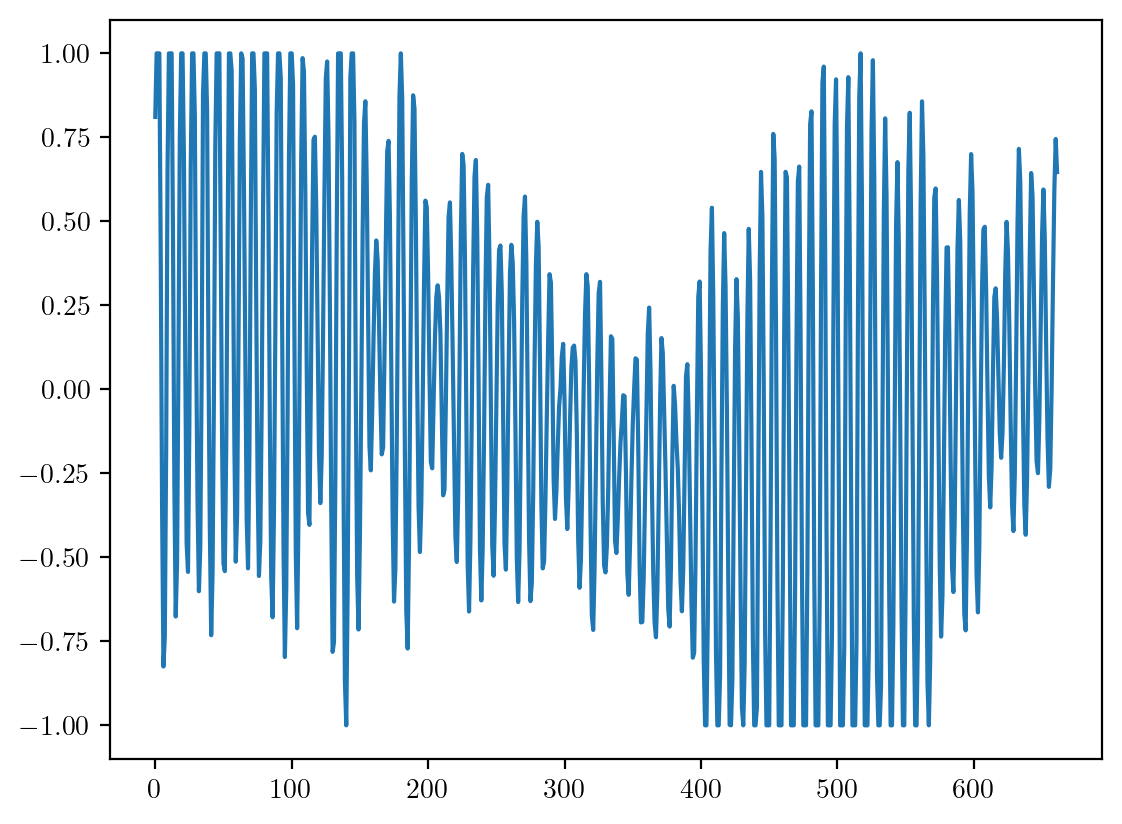

NameError: name 'get_spec' is not defined

In [9]:
ax = plt.gca()

ax.plot(X_train[10,:,0])
#ax.plot(X_train[10,:,1])

plt.show()
plt.close()
spec, *_ = get_spec(X_train[10,:,-1],sr,onset=0,offset=X_train.shape[1]/sr,shoulder=0.0)
ax = plt.gca()
ax.imshow(spec,vmin=0,vmax=1,origin='lower')
plt.show()
plt.close()

In [ ]:
forwardConfig = MambaConfig(d_model=data_domain.shape[-1]+10, n_layers=2,d_state=16,d_conv=4,expand_factor=1)
reverseConfig = MambaConfig(d_model=data_domain.shape[-1]*2, n_layers=2,d_state=16,d_conv=4,expand_factor=1)

forwardModel = Mamba(forwardConfig).to("cuda")
reverseModel = Mamba(reverseConfig).to("cuda")
causal_filter = torch.nn.Linear(data_domain.shape[-1]*2,10).to('cuda')
opt = Adam(list(forwardModel.parameters()) +list(reverseModel.parameters()) + list(causal_filter.parameters()),
            lr=1e-5)
scheduler = ReduceLROnPlateau(opt,factor=0.75,patience=25,min_lr=1e-10)

In [ ]:
tl,vl,model,opt = train(forwardModel,reverseModel,causal_filter,opt,sr=sr,cutoff_freq=500,loss_fn=torch.nn.MSELoss(),loaders=dls,scheduler=scheduler,nEpochs=150,val_freq=20)

training model:  91%|█████▍| 136/150 [1:36:00<09:50, 42.18s/it]

In [232]:
## make better reconstruction visualization here

In [ ]:
sd = {'forward_model': model[0].state_dict(),
      'reverse_model': model[1].state_dict(),
      'projection': model[2].state_dict(),
      'opt':opt.state_dict()}
save_loc = '/home/miles/isilon/All_Staff/miles/models/mamba/blk417_ouroboros_dyonly_shortcontext.tar'
torch.save(sd,save_loc)

In [ ]:
load_loc = '/home/miles/isilon/All_Staff/miles/models/mamba/blk417_ouroboros_silu.tar'
state = torch.load(load_loc,weights_only=True)
forwardModel.load_state_dict(state['forward_model'])
reverseModel.load_state_dict(state['reverse_model'])
causal_filter.load_state_dict(state['projection'])
opt.load_state_dict(state['opt'])
model = (forwardModel,reverseModel,causal_filter)

In [199]:
visualize_recons(model,audios,sr,voctimes,n_samples=5)

TypeError: list indices must be integers or slices, not tuple

In [ ]:
def model_wrapper(data,models,mask_aud=False):

    forward_model,reverse_model,projection = models

    #print(data.shape)
    dy = data[:,1:,:] - data[:,:-1,:]
    #print(dy.shape)
    pred_state = reverse_model(torch.cat([dy,data[:,1:,:]],dim=-1).to('cuda'))
    #print(pred_state.shape)
    #print(pred_state.shape)
    proj_state = torch.nn.SiLU()(projection(pred_state))
    #proj_state = lowpass_biquad(proj_state,sample_rate=sr,cutoff_freq=1000)
    #print(proj_state.shape)
    #print(proj_state.shape)
    if mask_aud:
        data[:,:-1,:] = 0.
    #print(data.shape)
    #print(proj_state.shape)
    yhat = forward_model(torch.cat([proj_state,data[:,:-1,:]],dim=-1))
    #print(yhat.shape)
    return yhat,proj_state

                                          
    

NameError: name 'tl' is not defined

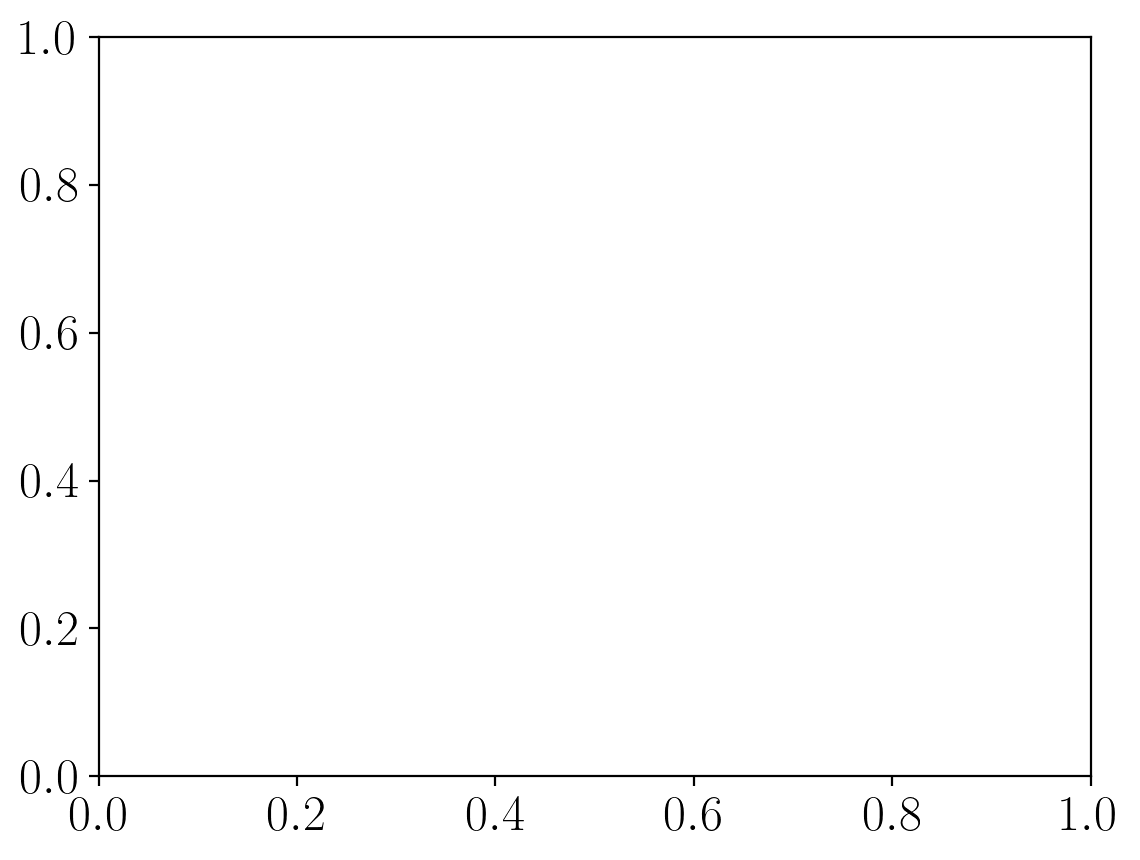

In [15]:
ax = plt.gca()
ax.plot(tl,color='tab:blue',label='train loss')

#plt.show()
#plt.close()
#ax = plt.gca()
vl = np.array(vl)
ax.plot(vl[:,0],vl[:,1],color='tab:orange',label='val loss')
ax.set_title("losses")
plt.legend()
ax.set_xlabel("gradient updates")
ax.set_ylabel("loss (MSE)")
plt.show()
plt.close()

In [ ]:
import warnings
%matplotlib inline

import matplotlib

matplotlib.rcParams['text.usetex']=True
font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 18}

matplotlib.rc('font', **font)

def from_numpy(data,device='cuda'):

    return torch.from_numpy(data).type(torch.FloatTensor).to(device)

def generate_fancy_figure(model,wavdir,roidir,nSamples=10):

    plot_struct = """
    AA
    BB
    CC
    """
    wavs = glob.glob(os.path.join(wavdir,'*.wav'))
    wavs.sort()
    segs = glob.glob(os.path.join(roidir,'*.txt'))
    segs.sort()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        segLens = [len(np.loadtxt(s).reshape(-1,2)) if len(np.loadtxt(s)) > 0  else 0 for s in segs ]
    weights = np.array(segLens)/np.sum(segLens)

    samples = np.random.choice(len(wavs),nSamples,p=weights)

    for jj,s in enumerate(samples):
        w,r = wavs[s],segs[s]
        onoffs = np.loadtxt(r)
        sr,audio = wavfile.read(w)
        analytic_signal = hilbert(audio)
        envelope=np.abs(analytic_signal)
        if audio.dtype == np.int16:
            audio = audio/-np.iinfo(audio.dtype).min
            
        if len(onoffs.shape)==1:
            onoffs = onoffs[None,:]
        roiChoice = np.random.choice(len(onoffs))
        onoff = onoffs[roiChoice]

        ### Get original data
        aud,_ = get_audio(audio,sr,onoff[0],onoff[1],envelope=envelope,env=False)
        spec,*_ = get_spec(aud[1:,-1],sr,onset=0,offset=len(aud)/sr,shoulder=0.0)

        ### format and pass through model
        aud = aud[None,:,:]
        print(aud.shape)
        nextPredictionFull,projStateFull=model_wrapper(from_numpy(aud),model,mask_aud=False)

        nextPredictionFull = nextPredictionFull[:,:,-1] + from_numpy(aud[:,:-1,-1])

        ### get prediction spectrogram
        predAudFull = nextPredictionFull.detach().cpu().numpy().squeeze()#[:,-1] +sampleAud[:-1]

        predSpecFull,t,f,_ = get_spec(predAudFull,sr,onset=0,offset=len(predAudFull)/sr,shoulder=0.)
        
        #print(nextPredictionFull.shape)
        #print(projStateFull.shape)
        
        ### set up plot
        fig,axs = plt.subplot_mosaic(plot_struct,layout='compressed',figsize=(15,10),height_ratios=[1,1,1])
        
        ### add spectrograms from real data, predicted specs
        axs['A'].imshow(spec,vmin=0,vmax=1,origin='lower',aspect='auto')
        axs['B'].imshow(predSpecFull,vmin=0,vmax=1,origin='lower',aspect='auto')
        axs['A'].set_title("Data")
        axs['B'].set_title("Reconstruction")
        axs['A'].set_xticks([])
        #yticks = axs['A'].get_yticks()
        #fVals = np.linspace(f[0],f[-1],len(yticks))
        #axs['A'].set_yticks(yticks,fVals)
        axs['A'].set_yticks([])
        axs['B'].set_xticks([])
        axs['B'].set_yticks([])
        axs['A'].set_rasterization_zorder(20)
        axs['B'].set_rasterization_zorder(20)

        ### add control inputs
        projStateFull = projStateFull.detach().cpu().numpy().squeeze()
        mu = np.nanmean(projStateFull,axis=0,keepdims=True)
        
        cov = (projStateFull-mu).T @ (projStateFull - mu)/len(projStateFull)
        try:
            vals,_ = np.linalg.eigh(cov)
            varExplained = np.cumsum(np.flip(vals)/np.sum(vals))
            print(varExplained)
        except:
            print("eigs didn't converge, skipping")
        
        print("Variance explained per PC: ", np.cumsum(vals/np.sum(vals)))

        vertShift = np.amax(np.abs(projStateFull))
        vertShift += vertShift/10

        mus = np.nanmean(projStateFull,axis=0)
        timeAx = np.arange(0,len(projStateFull)/sr,1/sr)
        for dim in range(projStateFull.shape[-1]):
            axs['C'].plot(timeAx,projStateFull[:,dim] - mus[dim] - vertShift*dim)

        labels = [f"Latent dimension {ii+1}" for ii in range(projStateFull.shape[-1])]
        inds = [- vertShift*ii for ii,mu in enumerate(mus)]

        axs['C'].set_yticks(inds,labels)
        axs['C'].set_xlim([timeAx[0],timeAx[-1]])
        axs['C'].set_xlabel("Time (s)")
        axs['C'].spines['top'].set_visible(False)
        axs['C'].spines['right'].set_visible(False)
        
        #plt.tight_layout()
        plt.savefig(f'/home/miles/Downloads/example_ouroboros_{jj+1}.png',dpi=600)
        plt.show()
        plt.close()
        #assert False
        
        
        

generate_fancy_figure(model,ap,sp)
    



In [ ]:
from matplotlib.colors import Normalize
def generate(model,sample,sr,context_len=0.03):

    #sample = torch.from_numpy(sample).type(torch.FloatTensor).to('cuda')
    caches = [(None, torch.zeros((1,sample.shape[-1],3),device='cuda')) for _ in model.layers]

    init_end = int(round(context_len *  sr))

    init_data = sample[:init_end,:]
    gen_init = sample[init_end:init_end+1,:]
    N = sample.shape[0]

    for ii in range(init_data.shape[1]):
        """
        print(init_data[:,ii,:].shape)
        x2 = model.layers[0].mixer.in_proj(init_data[:,ii,:])
        print(x2.shape)
        h, inputs = caches[0]
        
        x, z = x2.chunk(2, dim=1) # (B, ED), (B, ED)

        # x branch
        x_cache = x.unsqueeze(2)
        print(x_cache.shape)
        print(inputs.shape)
        print(x.shape,z.shape)
        x = model.layers[0].mixer.conv1d(torch.cat([inputs, x_cache], dim=2))[:, :, model.layers[0].mixer.config.d_conv-1] 
        """
        x,caches = model.step(init_data[:,ii,:],caches)

    gen_data = [init_data,gen_init]

    
    for ii in range(init_end,N-1):

        sample,caches = model.step(gen_data[ii],caches)
        gen_data.append(gen_data[ii] + sample)

    return torch.vstack(gen_data)

def from_numpy(data,device='cuda'):

    return torch.from_numpy(data).type(torch.FloatTensor).to(device)

def visualize_recons(model,audio,sr,voctimes,n_samples=15):

    #if filter: 
    #vmapped_filter = torch.vmap(filter,in_axis=3,out_axis=3)
        
    for _ in range(n_samples):
        sample = np.random.choice(len(voctimes))
        sampleAud,audTimes = get_audio(audio,sr,voctimes[sample][0],voctimes[sample][1])
        #sampleAud,sampleSpikes,*_ = get_audio_rate_pairs(audio,sr,spiketimes,voctimes[sample][0],voctimes[sample][1],data_type=data_type)
        
        #minLen = min(len(sampleAud),sampleSpikes.shape[-1])
        #sampleSpikes,sampleAud = sampleSpikes[:,:minLen],sampleAud[:minLen]
        #ax = plt.gca()
        #for s in sampleSpikes:
        #    ax.plot(s)
        #ax.set_ylabel("rate")
        #plt.show()
        #plt.close()

        originalSample=sampleAud[None,:,None]#np.vstack([sampleSpikes,sampleAud]).T[None,:,:]
        print(originalSample.shape)
        #maskedNeur = np.vstack([np.zeros(sampleSpikes.shape),sampleAud]).T[None,:,:]
        #maskedAud = np.vstack([sampleSpikes,np.zeros(sampleAud.shape)]).T[None,:,:]
        ####
        #meanNeur = np.vstack([np.tile(np.nanmean(sampleSpikes,axis=-1,keepdims=True),(1,sampleSpikes.shape[-1])),np.zeros(sampleAud.shape)] ).T[None,:,:]
        #print(meanNeur.shape)
        #print(maskedAud.shape)
        ## should give mean firing rate for whole vocalization
        
        spec,*_ = get_spec(sampleAud[1:],sr,onset=0,offset=len(sampleAud)/sr,shoulder=0.0)
        
        #gen_sample = generate(model,originalSample,sr,context_len=0.03)[:,:,-1]
        #nextPredictionNeur = generate(model,maskedNeur,sr,context_len=0.03)[:,:,-1]
        nextPredictionFull,projStateFull=model_wrapper(from_numpy(originalSample),model,mask_aud=False)
        nextPredictionState,_ =model_wrapper(from_numpy(originalSample),model,mask_aud=True)
        nextPredictionFull = nextPredictionFull[:,:,-1] + from_numpy(sampleAud[:-1])
        nextPredictionState = nextPredictionState[:,:,-1] + from_numpy(sampleAud[:-1])
        
        projStateFull = projStateFull.detach().cpu().numpy().squeeze()
        mu = np.nanmean(projStateFull,axis=0,keepdims=True)
        _,s,vh = np.linalg.svd(projStateFull-mu)

        projStateFull = (projStateFull-mu)@vh.T
        print(np.cumsum(s**2/np.sum(s**2)))
        #print(projStateFull.shape)
        #nextPredictionAud=model(from_numpy(maskedNeur[:,:-1,:]))[:,:,-1] + from_numpy(sampleAud[:-1])
        #nextPredictionNeur=model(from_numpy(maskedAud[:,:-1,:]))[:,:,-1] + from_numpy(sampleAud[:-1])
        #nextPredictionNone=model(from_numpy(meanNeur[:,:-1,:]))[:,:,-1] + from_numpy(sampleAud[:-1])

        #gen_sampleFull = gen_sample.detach().cpu().numpy().squeeze()
        #genSpecFull,*_ = get_spec(gen_sampleFull,sr,onset=0,offset=len(gen_sampleFull)/sr,shoulder=0.)
        
        predAudFull = nextPredictionFull.detach().cpu().numpy().squeeze()#[:,-1] +sampleAud[:-1]
        predSpecFull,*_ = get_spec(predAudFull,sr,onset=0,offset=len(predAudFull)/sr,shoulder=0.)
        
        predAudState = nextPredictionState.detach().cpu().numpy().squeeze()#[:,-1] +sampleAud[:-1]
        predSpecState,*_ = get_spec(predAudState,sr,onset=0,offset=len(predAudState)/sr,shoulder=0.)
        
        #predAudNeur = nextPredictionNeur.detach().cpu().numpy().squeeze()#[:,-1] +sampleAud[:-1]
        #predSpecNeur,*_ = get_spec(predAudNeur,sr,onset=0,offset=len(predAudNeur)/sr,shoulder=0.)
        
        #predAudNone = nextPredictionNone.detach().cpu().numpy().squeeze()#[:,-1]+sampleAud[:-1]
        #predSpecNone,*_ = get_spec(predAudNone,sr,onset=0,offset=len(predAudNone)/sr,shoulder=0.)

        fig,axs = plt.subplots(nrows=1,ncols=5,figsize=(20,7))
        axs[0].imshow(spec,vmin=0,vmax=1,origin='lower')
        axs[1].imshow(predSpecFull,vmin=0,vmax=1,origin='lower')
        axs[2].imshow(predSpecState,vmin=0,vmax=1,origin='lower')
        #axs[3].imshow(predSpecNeur,vmin=0,vmax=1,origin='lower')
        #axs[4].imshow(predSpecNone,vmin=0,vmax=1,origin='lower')
        axs[0].set_title("Data")
        axs[1].set_title("Reconstruction, full input")
        #axs[2].set_title("Generated spec from full input")
        #axs[3].set_title("Reconstruction, neural only")
        #axs[4].set_title("Reconstruction, mean neural + audio")
        plt.show()
        plt.close()

        fig,(ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(10,5))
        ax1.plot(sampleAud[101:201],color='tab:blue',label='True audio')
        ax1.plot(predAudFull[100:200],color='tab:orange',label='Predicted audio (full dataset)')
        ax1.plot(predAudState[100:200],color='tab:green',label='Predicted audio (reverse model state)')
        #ax1.plot(predAudNeur[101:201],color='tab:brown',label='Generated audio (neural only)')
        #ax1.plot(predAudNone[101:201],color='tab:purple',label='Predicted audio (no inputs)')

        ax1.set_ylim([np.amin(sampleAud)-0.1,np.amax(sampleAud)+0.1])
        ax1.legend()
        mseReal = np.nanmean((sampleAud[1:] - sampleAud[:-1])**2)
        #mseGen = np.nanmean((sampleGen - sampleAud)**2)
        mseFull = np.nanmean((predAudFull - sampleAud[1:])**2)
        #mseAud = np.nanmean((predAudAud - sampleAud[1:])**2)
        #mseNeur = np.nanmean((predAudNeur - sampleAud[1:])**2)
        #mseNone = np.nanmean((predAudNone - sampleAud[1:])**2)

        for latent_dim in range(projStateFull.shape[-1]):
            ax2.plot(projStateFull[100:200,latent_dim],label=f'PC {latent_dim+1}')
        
        #ax2.set_ylabel("MSE")
        #ax2.tick_params(axis='x',labelrotation=45)
        
        #ax2.bar(list(range(2)),[mseReal,mseFull],color=['tab:orange','tab:green'])
        #ax2.set_xticks(list(range(2)),['True dy', 'All inputs'],rotation=45)
        ax2.legend()
        plt.tight_layout()
        plt.show()
        plt.close()

        time = np.arange(0,len(projStateFull)/sr,1/sr)
        scale_factor = time*2
        projNorm = np.linalg.norm(projStateFull,axis=-1,keepdims=True)
        scaledStates = projStateFull/projNorm *(projNorm + scale_factor[:,None])
        norm = Normalize(vmin=0,vmax=np.amax(time))
        ax = plt.gca()
        ax.plot(scaledStates[:,0],scaledStates[:,1],linewidth=1)
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        plt.show()
        plt.close()

        fig = plt.figure()
        ax1 = fig.add_subplot(111,projection='3d')
        #print(np.amin(time),np.amax(time))
        #print(projStateFull.shape)
        ax1.plot(time,projStateFull[:,0],projStateFull[:,1],time,linewidth=1,alpha=0.7)
        ax1.set_ylabel("PC 1")
        ax1.set_zlabel("PC 2")
        #ax1.set_xlabel("time")
        plt.legend()
        plt.show()
        plt.close()


def get_spec(audio,fs,onset,offset,shoulder=0.05,n_freq_bins = 64):

    """
    make a spectrogram for a given vocalization.
    """
    flag = 0
    if offset - onset <= 0.05:
        flag = 1
    audiotimes = np.linspace(0,len(audio)/fs,len(audio))
    a,t = audio[np.searchsorted(audiotimes,onset-shoulder):np.searchsorted(audiotimes,offset+shoulder)],\
        audiotimes[np.searchsorted(audiotimes,onset-shoulder):np.searchsorted(audiotimes,offset+shoulder)]
    N = len(t)
    w = hann(128, sym=True)  # symmetric Gaussian window
    #print(f"{offset-onset} s long audio")

    transform = STFFT(w,hop=16,fs=fs,mfft = 1028)

    Sx = transform.stft(a)
    
    t_lo,t_hi,f_lo,f_hi = transform.extent(N)
    tAx = np.linspace(t_lo,t_hi,Sx.shape[1]) + onset
    
    t0,t1 = np.searchsorted(tAx,onset),np.searchsorted(tAx,offset)

    Sx,tAx = Sx[:,t0:t1],tAx[t0:t1]

    #print(Sx.shape)
    #print(f_lo,f_hi)

    fAx = np.linspace(f_lo,f_hi,Sx.shape[0])
    fAx_mels = _mel(fAx)
    target_freqs = np.linspace(f_lo,f_hi,n_freq_bins)
    target_ts = np.arange(tAx[0],tAx[-1],0.001)

    Sx = np.log(np.abs(Sx) + 1e-12)
    Sx = (Sx + 2.5) / 5
    Sx = np.clip(Sx, 0.0, 1.0)

    interp = RegularGridInterpolator((fAx,tAx),Sx,bounds_error=True,fill_value=-1e10)
    #make_interp_spline(fAx,np.log(np.abs(Sx)+1e-10),axis=0)
    newX,newY = np.meshgrid(target_freqs,target_ts,indexing='ij',sparse=True)
    #print(np.amin(newX),np.amax(newX),np.amin(fAx),np.amax(fAx))
    #print(np.amin(newY),np.amax(newY),np.amin(tAx),np.amax(tAx))
    Sx2 = interp((newX,newY))
    Sx = Sx2
    #Sx = Sx2
    """
    print(Sx.shape)
    print(Sx2.shape)
    print(f'spec dt: {tAx[1] - tAx[0]}')
    fig,axs = plt.subplots(nrows=1,ncols=2)
    axs[0].imshow(Sx,extent = transform.extent(N),origin='lower',aspect='auto')
    axs[1].imshow(Sx2,origin='lower',aspect='auto',extent=transform.extent(N))
    
    plt.show()
    plt.close()
    
    #assert False
    """
    
    return Sx,target_ts,target_freqs,flag